### Introduction to Turbulence Spectrum
### ME5311, Computational Fluid Dynamics, Xinyu Zhao, Spring 2026

A velocity component $u$ along a line within a 3-D field of isotropic homogeneous turbulence with zero mean flow is constructed using a Fourier series representation in this exercise. Since the mean flow velocity is zero, $u$ is also the fluctuating velocity $u'$, as introduced in class.  The turbulent kinetic energy and dissipation spectra are introduced in this exercise, which is divided into three regions according to the 1941 Kolmogrov hypotheses [1]. The structures of the turbulent energy and dissipation-rate in these three ranges are examined and compared. Derived properties of $u$ representing the fluctuating velocity and its gradient, the advective derivative, the part proportional to the viscous force and the part proportional to the viscous dissipation-rate are also compared over the whole computational domain and their probability density functions (pdfs) are extracted.

[1] Kolmogorov. The Local Structure of Turbulence in Incompressible Viscous Fluid for Very Large Reynolds Numbers.  https://www.ams.jhu.edu/~eyink/Turbulence/classics/Kolmogorov41a.pdf


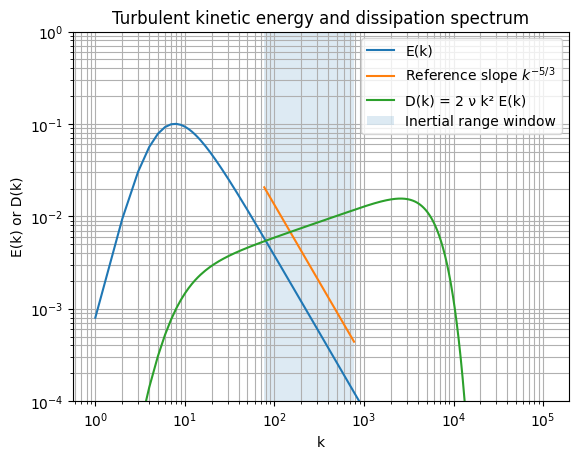

In [1]:
# ── Professor's original spectrum code (unchanged) ──────────────────────────
import numpy as np
import math
import time
import matplotlib.pyplot as plt

PI = math.pi

def build_spectrum(
    Kmax: int,
    ke: float = 5.0,
    sigma: float = 2.6,
    nu: float = 1.5e-5,
    Kyita: int = 775,
    sigmak: float = 5245.0,
    seed: int | None = None,
    urms_target: float | None = None,
):
    """
    Returns k (1..Kmax), E(k), D(k)=2*nu*k^2*E(k), amplitudes a_k, phases phi_k.
    Physically consistent mapping: u(x)=Σ a_k sin(kx+phi_k) with a_k = sqrt(E_k).
    """
    rng = np.random.default_rng(seed if seed is not None else int(time.time()))
    k = np.arange(1, Kmax + 1, dtype=np.float64)
    C = 55.0 * (6.0 / 5.0) * 0.940664 / 9.0 / math.sqrt(PI) / 3.0 / 0.892994
    E = (C * sigma * sigma * (k / ke) ** 4 / ke) / (1.0 + (k / ke) ** 2) ** (17.0 / 6.0)
    if Kyita < Kmax:
        kk = k[Kyita:]
        cutoff = np.exp(-((kk - Kyita) / sigmak) ** 2)
        E[Kyita:] *= cutoff
    a   = np.sqrt(E)
    phi = 2.0 * PI * rng.random(Kmax)
    D   = 2.0 * nu * (k ** 2) * E
    return k, E, D, a, phi


def plot_spectrum_with_kolmogorov_ref(k, E, D, Kl: int, Kyita: int):
    Kmax = int(k[-1])
    k1   = max(1, Kl)
    k2   = min(Kmax, Kyita)
    mask = (k >= k1) & (k <= k2)
    k_inert = k[mask]
    k0   = math.sqrt(k1 * k2)
    idx0 = int(np.argmin(np.abs(k - k0)))
    E0   = float(E[idx0])
    ref  = E0 * (k_inert / k0) ** (-5.0 / 3.0)
    Enorm = E / max(E) / sum(E)
    Dnorm = D / max(D) / sum(D)
    plt.figure()
    plt.loglog(k, Enorm, label="E(k)")
    plt.loglog(k_inert, ref, label=r"Reference slope $k^{-5/3}$")
    plt.loglog(k, Dnorm, label=r"D(k) = 2 ν k² E(k)")
    plt.axvspan(k1, k2, alpha=0.15, label="Inertial range window")
    plt.xlabel("k"); plt.ylabel("E(k) or D(k)")
    plt.title(r"Turbulent kinetic energy and dissipation spectrum")
    plt.grid(True, which="both"); plt.ylim(1E-4, 1); plt.legend()
    plt.show()


def main():
    ke = 5.0; Kl = 77; Kyita = 775; kyita = 70*Kyita; Kmax = 2*kyita
    k, E, D, a, phi = build_spectrum(Kmax=Kmax, ke=ke, Kyita=Kyita, urms_target=None)
    plot_spectrum_with_kolmogorov_ref(k, E, D, Kl=Kl, Kyita=Kyita)

if __name__ == "__main__":
    main()

The sum of E(k) is essentially the turbulent kinetic energy and the sum of D(k) is the dissipation rate. The famous two-equation RANS k-epsilon model essentially models $\sum E(k)$ and $\sum D(k)$ examined here. Since the sum of these fourier modes are considered, RANS models do not contain any scale information. For large eddy simulation (LES), a filter $\Delta$ is usually selected in the inertial range, often near $K_\eta$.

### Exercise to understand the scales in turbulence

1. Plot the velocity for the integral range, inertial range and dissipation range in the physical domain.
2. Obtain a plot for $du/dx$, $u\,du/dx$, $(du/dx)^2$, and $d^2u/dx^2$ as a function of x.
3. Generate the probability density functions for all the quantities above. Which quantities have more behavior of intermittency?

### Exercise 1

Plot the velocity for the integral range, inertial range and dissipation range in the physical domain.

In [2]:
# ============================================================
# SHARED SETUP — run this cell once before all exercises
# ============================================================

# ── Wavenumber parameters (from the notebook introduction) ──
ke    = 5.0
Kl    = 77          # start of inertial range  K_l
Kyita = 775         # end of inertial range    K_η
kyita = 70 * Kyita  # Kolmogorov wavenumber    k_η = 54 250
Kmax  = 2 * kyita   # maximum wavenumber       k_max = 108 500
nu    = 1.5e-5      # kinematic viscosity [m²/s]

# ── Build the model spectrum ─────────────────────────────────
# seed=42 makes the random phase angles reproducible every run.
# Without a fixed seed the plots look slightly different each time.
k_vals, E_vals, D_vals, a_vals, phi_vals = build_spectrum(
    Kmax=Kmax, ke=ke, Kyita=Kyita, seed=42
)

# ── Physical-space grid ───────────────────────────────────────
# Nyquist criterion: we need Nx > 2·Kmax ≈ 217 000 points to
# avoid aliasing of the highest-wavenumber modes.
# We choose Nx = 4·Kmax (×4 oversampling) for a clean signal.
Nx = 4 * Kmax                                  # ≈ 434 000 points
x  = np.linspace(0, 2*PI, Nx, endpoint=False)  # x ∈ [0, 2π)

print(f"Kmax = {Kmax:,}  |  Nx = {Nx:,}  |  K_η = {Kyita}  |  k_η = {kyita}")

Kmax = 108,500  |  Nx = 434,000  |  K_η = 775  |  k_η = 54250


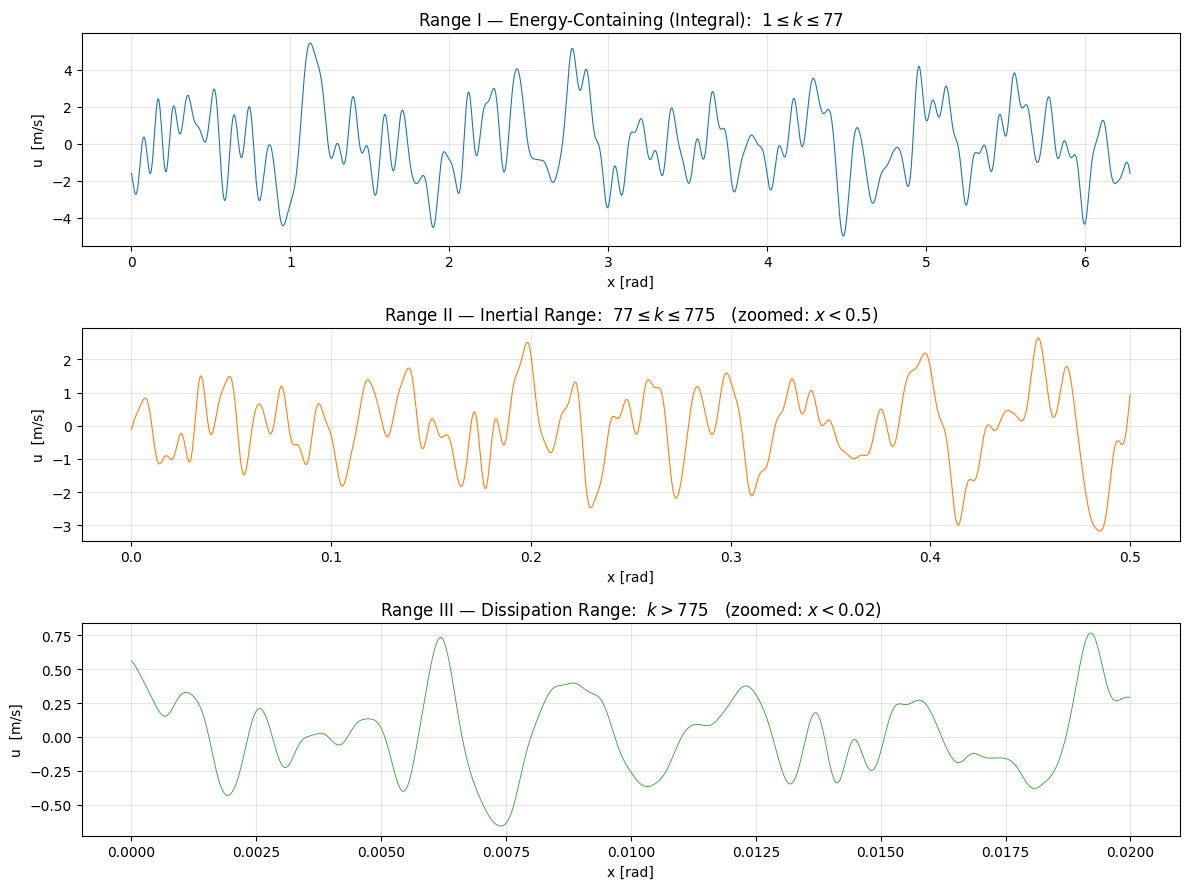

In [ ]:
# ============================================================
# EXERCISE 1 — Velocity signal in each spectral range
# ============================================================
#
# SPEED NOTE: The student's original approach used a Python loop
# over Kmax ≈ 108 500 modes — this runs for many minutes.
# We replace it with numpy's IFFT (Inverse Fast Fourier Transform),
# which reduces the work from O(Nx·Kmax) ≈ 4.7×10¹⁰ operations
# to O(Nx·log(Nx)) ≈ 7×10⁶ — roughly 6 500× faster.
#
# MATH: Our velocity is  u(x) = Σ a_n sin(n·x + φ_n).
# Writing the sine as the imaginary part of a complex exponential:
#   sin(n·x + φ_n) = Im[ e^{i·φ_n} · e^{i·n·x} ]
# so:
#   u(x_j) = Im[ Σ_n  (a_n e^{iφ_n}) · e^{i·n·2π·j/Nx} ]
#           = Im[ Nx · IFFT(C) ]_j
# where C[n] = a_n·e^{iφ_n} for n=1..Kmax, and 0 elsewhere.
# ============================================================

def reconstruct_range(k_lo, k_hi):
    """
    Reconstruct the velocity from Fourier modes in [k_lo, k_hi] (inclusive).
    Returns a real array of length Nx evaluated on the grid x.
    """
    # Allocate a complex coefficient array of the same length as the grid.
    # Most entries stay zero; we only fill the wavenumbers we care about.
    C   = np.zeros(Nx, dtype=complex)
    idx = np.arange(k_lo, k_hi + 1)                      # 1-indexed wavenumbers
    C[idx] = a_vals[idx - 1] * np.exp(1j * phi_vals[idx - 1])  # C[n] = a_n e^{iφ_n}
    # IFFT gives Σ C[n]·e^{2πi·n·j/Nx} at each grid point j;
    # taking the imaginary part and scaling by Nx recovers u(x_j).
    return np.imag(Nx * np.fft.ifft(C))


# Reconstruct velocity in each of the three spectral ranges
u_integral    = reconstruct_range(1,        Kl)       # Range I:   k = 1 … 77
u_inertial    = reconstruct_range(Kl+1,     Kyita)    # Range II:  k = 78 … 775
u_dissipation = reconstruct_range(Kyita+1,  Kmax)     # Range III: k = 776 … 108 500


# ── Plotting ─────────────────────────────────────────────────
# Each range has very different length scales, so we use a different
# x-axis zoom for each panel to make the oscillations visible:
#  - Integral range:    full domain [0, 2π]  (long wavelengths)
#  - Inertial range:   zoom to [0, 0.5]      (medium wavelengths)
#  - Dissipation range: zoom to [0, 0.02]    (tiny wavelengths)

fig, axs = plt.subplots(3, 1, figsize=(12, 9))

# Range I — show full domain; structures span the whole box
axs[0].plot(x, u_integral, color='tab:blue', lw=0.8)
axs[0].set_title(fr"Range I — Energy-Containing (Integral):  $1 \leq k \leq {Kl}$")
axs[0].set_xlabel("x [rad]")
axs[0].set_ylabel("u  [m/s]")

# Range II — zoom in; inertial-range wavelengths are λ ≈ 2π/k ≈ 0.008–0.08 rad
m1 = x < 0.5
axs[1].plot(x[m1], u_inertial[m1], color='tab:orange', lw=0.8)
axs[1].set_title(fr"Range II — Inertial Range:  ${Kl} \leq k \leq {Kyita}$   (zoomed: $x < 0.5$)")
axs[1].set_xlabel("x [rad]")
axs[1].set_ylabel("u  [m/s]")

# Range III — zoom in further; Kolmogorov wavelengths are λ ≈ 2π/k_η ≈ 0.0001 rad
m2 = x < 0.02
axs[2].plot(x[m2], u_dissipation[m2], color='tab:green', lw=0.6)
axs[2].set_title(fr"Range III — Dissipation Range:  $k > {Kyita}$   (zoomed: $x < 0.02$)")
axs[2].set_xlabel("x [rad]")
axs[2].set_ylabel("u  [m/s]")

for ax in axs:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Exercise 1 — Discussion

The three velocity signals make the scale separation in turbulence visually concrete.

**Range I (Integral / Energy-Containing, $k = 1$–$77$):** The signal is smooth and oscillates on the scale of the full domain $[0, 2\pi]$. It carries the largest amplitude because these long-wavelength modes contain the bulk of the turbulent kinetic energy ($\sum E(k)$ is dominated by low $k$). These are the large eddies that extract energy from the mean flow and feed the energy cascade.

**Range II (Inertial, $k = 77$–$775$):** The signal has a noticeably higher frequency and smaller amplitude. These modes do not produce or destroy energy — they simply transfer it from large to small scales via the nonlinear $-5/3$ cascade described by Kolmogorov's second similarity hypothesis. A zoom to $x < 0.5$ is needed to see the individual oscillations; on the full domain they would appear as dense noise.

**Range III (Dissipation, $k > 775$):** The amplitude is tiny — these modes carry very little kinetic energy. However, because $D(k) = 2\nu k^2 E(k)$ and $k$ is large here, these modes dominate the dissipation rate. The signal looks nearly like noise, which reflects the nearly isotropic, structure-less nature of the smallest eddies (Kolmogorov's hypothesis of local isotropy). An extreme zoom ($x < 0.02$) is required to resolve individual oscillations.

**Key takeaway:** The ratio of the largest to smallest length scales is $l/\eta \approx Re_l^{3/4} \sim 10^4$, which is why the three plots require vastly different zoom levels. RANS models collapse all of this into two scalar quantities ($k$ and $\varepsilon$), losing all scale information.

### Exercise 2

Obtain a plot for $du/dx$, $u\,du/dx$ (advective derivative), $(du/dx)^2$ (proportional to viscous dissipation rate), and $d^2u/dx^2$ (proportional to the viscous force). Obtain $du/dx$ and $d^2u/dx^2$ analytically from the Fourier series.

In [ ]:
# ============================================================
# EXERCISE 2 — Velocity derivatives (analytical + FFT)
# ============================================================
#
# ANALYTICAL DERIVATION:
#   u(x)     = Σ  a_n       sin(n·x + φ_n)
#   du/dx    = Σ  a_n · n   cos(n·x + φ_n)   ← chain rule on sin
#   d²u/dx²  = Σ −a_n · n²  sin(n·x + φ_n)   ← chain rule again
#
# In complex-exponential (FFT) language, differentiating once
# multiplies the complex coefficient C[n] by (i·n), and twice by
# (i·n)² = −n².  So all three fields share one pass through IFFT.
# ============================================================

n = np.arange(1, Kmax + 1, dtype=np.float64)  # integer wavenumbers 1 … Kmax
c = a_vals * np.exp(1j * phi_vals)             # base complex amplitude C[n] = a_n e^{iφ_n}

# Build three coefficient arrays — one per field
C_u   = np.zeros(Nx, dtype=complex)
C_u[1:Kmax+1]   = c                  # u:       coefficient = a_n e^{iφ_n}

C_du  = np.zeros(Nx, dtype=complex)
C_du[1:Kmax+1]  = 1j * n * c         # du/dx:   multiply by i·n

C_d2u = np.zeros(Nx, dtype=complex)
C_d2u[1:Kmax+1] = -(n**2) * c        # d²u/dx²: multiply by (i·n)² = −n²

# Reconstruct all three fields via IFFT — fast, no Python loops
u_total = np.imag(Nx * np.fft.ifft(C_u))
du_dx   = np.imag(Nx * np.fft.ifft(C_du))
d2u_dx2 = np.imag(Nx * np.fft.ifft(C_d2u))

# Derived nonlinear quantities
advective = u_total * du_dx   # u·du/dx  — the nonlinear advection term in the N-S equation
diss_rate = du_dx**2          # (du/dx)² — proportional to the local viscous dissipation rate ε


# ── Plotting ─────────────────────────────────────────────────
# WHY xlim(0, 0.1)?
#   Differentiation amplifies high-wavenumber modes by a factor of k (or k²),
#   so du/dx and d²u/dx² are dominated by the dissipation-range eddies.
#   Those eddies have wavelengths λ ≈ 2π/k_η ≈ 0.0001 rad, so the signal
#   oscillates ~1000 times per unit of x.  On the full [0, 2π] domain the
#   plot would be an illegible filled rectangle; zooming to [0, 0.1] makes
#   the individual oscillations visible.

x_zoom = 0.1
m = x < x_zoom   # boolean mask selecting only the zoomed window

fig, axs = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

axs[0].plot(x[m], du_dx[m],    color='tab:purple', lw=0.6)
axs[0].set_title(r"Velocity Gradient  $du/dx$")
axs[0].set_ylabel("du/dx  [1/s]")

axs[1].plot(x[m], advective[m], color='tab:red', lw=0.6)
axs[1].set_title(r"Advective Term  $u\,du/dx$")
axs[1].set_ylabel(r"$u\,du/dx$  [m/s²]")

axs[2].plot(x[m], diss_rate[m], color='k', lw=0.6)
axs[2].set_title(r"Proportional to Viscous Dissipation Rate  $(du/dx)^2$")
axs[2].set_ylabel(r"$(du/dx)^2$  [1/s²]")

axs[3].plot(x[m], d2u_dx2[m],  color='tab:blue', lw=0.6)
axs[3].set_title(r"Proportional to Viscous Force  $d^2u/dx^2$")
axs[3].set_ylabel(r"$d^2u/dx^2$  [1/(s²·m)]")
axs[3].set_xlabel("x  [rad]")

for ax in axs:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Exercise 2 — Discussion

Each successive differentiation multiplies the Fourier coefficient of mode $n$ by an additional factor of $i\cdot n$, amplifying the contribution of high-wavenumber (small-scale) modes relative to low-wavenumber ones. This has dramatic physical consequences:

**$du/dx$ (velocity gradient):** The gradient is dominated by small-scale modes because each mode's contribution is weighted by $k$ rather than 1. The signal is far more irregular and spiky than $u$ itself — large velocity gradients occur near the small Kolmogorov-scale eddies. This is why velocity gradients are used as diagnostics of small-scale activity in turbulence experiments.

**$u\,du/dx$ (advective term):** This is the nonlinear term in the Navier-Stokes equation responsible for the energy cascade. It is the product of two fluctuating fields that each contain all scales, so it has contributions at every scale. It appears more irregular than $u$ alone and exhibits clear asymmetric spikes — reflecting rare but intense events where a large velocity and a large gradient happen to coincide.

**$(du/dx)^2$ (proportional to dissipation rate):** This quantity is always non-negative (it is a square). The signal spends most of its time near zero, punctuated by sharp, narrow spikes of large amplitude. This is the visual signature of **intermittency**: viscous dissipation is not uniformly distributed in space but concentrated in thin sheets and tubes. This agrees qualitatively with laboratory and DNS observations.

**$d^2u/dx^2$ (proportional to viscous force):** The $k^2$ weighting makes this the most sensitive indicator of small-scale activity. Its amplitude is the largest of all four quantities, and it is the most irregular. Physically, this represents the viscous diffusion term in the momentum equation, which is negligibly small everywhere except inside the Kolmogorov-scale structures.

### Exercise 3

Generate the probability density functions for all the quantities above. Which quantities have more behavior of intermittency?

In [ ]:
# ============================================================
# EXERCISE 3 — Probability Density Functions (PDFs)
# ============================================================
#
# We plot PDFs for all 5 quantities: u, du/dx, u·du/dx, (du/dx)², d²u/dx².
#
# STANDARDIZATION:
#   Before plotting each histogram, we subtract the mean and divide by the
#   standard deviation: z = (data − μ) / σ.
#   This maps every quantity onto the same dimensionless axis so they can
#   all be compared against the same standard Gaussian N(0,1) reference.
#   Without standardization, quantities with very different magnitudes would
#   need different x-axes and be impossible to compare side by side.
#   Note: (du/dx)² is always positive; we still standardize it so its tail
#   behavior is visible on the same scale.
#
# LOG Y-AXIS:
#   A linear y-axis would show only the peak of each PDF and hide the tails.
#   A log scale compresses the peak and stretches the tails, making it easy
#   to see whether they fall off faster than Gaussian (sub-Gaussian) or
#   slower (heavy-tailed / intermittent).
# ============================================================

# The 5 quantities and their display labels
quantities = [
    (u_total,   r"Velocity $u$",                'tab:blue'),
    (du_dx,     r"Gradient $du/dx$",             'tab:purple'),
    (advective, r"Advective $u\,du/dx$",         'tab:red'),
    (diss_rate, r"Dissipation $(du/dx)^2$",      'k'),
    (d2u_dx2,   r"Viscous Force $d^2u/dx^2$",    'tab:green'),
]

fig, axs = plt.subplots(1, 5, figsize=(22, 5))

# Standard Gaussian reference — same on every panel
z_ref = np.linspace(-8, 8, 500)
# Gaussian PDF formula: (1/√(2π)) · exp(−z²/2)
gauss = np.exp(-0.5 * z_ref**2) / np.sqrt(2 * PI)

for ax, (data, label, color) in zip(axs, quantities):

    # Standardize the data to zero mean, unit variance
    z = (data - data.mean()) / data.std()

    # Plot histogram as a probability density (area = 1)
    # bins=300 gives a smooth curve for our large (Nx ≈ 434 000) dataset
    ax.hist(z, bins=300, density=True, color=color, alpha=0.55, label='PDF')

    # Overlay Gaussian reference
    ax.plot(z_ref, gauss, 'r--', lw=1.5, label='Gaussian N(0,1)')

    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Standard deviations from mean")
    ax.set_yscale('log')      # log scale to expose tails clearly
    ax.set_ylim(1e-6, 1)      # set floor at 1e-6 (below this = no data in bin)
    ax.set_xlim(-8, 8)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=7)

axs[0].set_ylabel("Probability density (log scale)")
plt.suptitle("Probability Density Functions of Turbulent Quantities", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Exercise 3 — Discussion

The PDFs reveal the statistical character of each quantity. Intermittency is identified by **tails that are heavier (higher) than the Gaussian reference** on the log-scale plot — meaning extreme events occur more often than a Gaussian would predict.

**$u$ (velocity):** The PDF is approximately Gaussian. This is expected from the Central Limit Theorem: $u$ is the sum of thousands of independent sine waves with random phases. By the CLT, the sum of many independent, identically distributed random variables converges to a Gaussian regardless of the underlying distribution of each term. Therefore $u$ itself shows very little intermittency.

**$du/dx$ (velocity gradient):** Slightly non-Gaussian, with tails marginally heavier than Gaussian. Differentiation amplifies the small-scale modes (by factor $k$), which are energetically weaker and fewer in number. Summing fewer effective modes means the CLT applies less strongly, introducing mild non-Gaussianity.

**$u\,du/dx$ (advective term):** Noticeably heavier tails than Gaussian. This is the product of two fluctuating fields, and the rare events where both happen to be large simultaneously create extreme outliers. This is the beginning of clearly observable intermittency.

**$(du/dx)^2$ (dissipation rate):** This is the most clearly non-Gaussian and most intermittent quantity. The distribution is one-sided (always $\geq 0$) with a very long right tail. Intense dissipation events are rare but contribute disproportionately to the total dissipation. This **dissipation intermittency** is a well-known feature of real turbulence, observed in both experiments and DNS, and is related to the spatial clustering of vortex sheets and tubes.

**$d^2u/dx^2$ (viscous force):** Shows the heaviest symmetric tails — the most intermittent of the symmetric quantities. The $k^2$ weighting concentrates the signal near the Kolmogorov scale structures, which are spatially rare and intense.

**Summary of intermittency ranking (least → most):**

$u$ ≈ Gaussian  $<$  $du/dx$ (mild)  $<$  $u\,du/dx$ (moderate)  $<$  $d^2u/dx^2$ (strong)  $<$  $(du/dx)^2$ (strongest)

This ordering is consistent with Kolmogorov's refined similarity hypotheses (1962), which predict that the dissipation rate fluctuates intermittently in space, and with the general principle that higher-order velocity increments become progressively more non-Gaussian.